In [17]:
import polars as pl 
import matplotlib.pyplot as plt

In [33]:
df = pl.scan_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/train_df.parquet')

In [34]:
df.head().collect()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,source_user_type,destination_user_type,success
duration[μs],str,str,str,str,enum,enum,enum,enum,enum,bool
6d 8h 13m 45s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C12889""","""C1""","""NTLM""","""Network""","""LogOn""","""anon""","""anon""",true
6d 8h 13m 45s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1""","""C1""","""?""","""Network""","""LogOff""","""anon""","""anon""",true
12d 8h 33m 10s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1""","""C1""","""NTLM""","""Network""","""LogOn""","""anon""","""anon""",true
16d 13h 57m 28s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1""","""C1""","""?""","""Network""","""LogOff""","""anon""","""anon""",true
16d 13h 57m 28s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1191""","""C1""","""NTLM""","""Network""","""LogOn""","""anon""","""anon""",true


In [35]:
df2 = df.with_columns(pl.col('time').dt.total_days().alias('days')).select('days')
auth_per_day = df2.group_by('days').len().collect()
auth_per_day = auth_per_day.sort(by='days')

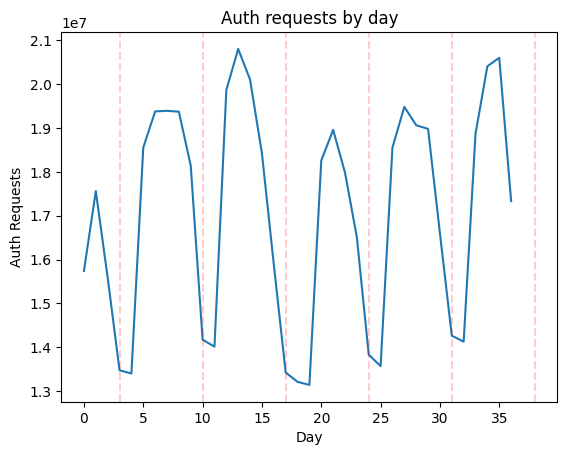

In [37]:
plt.plot(
    auth_per_day['days'].to_list(),
    auth_per_day['len'].to_list())
plt.title('Auth requests by day')
plt.xlabel('Day')
plt.ylabel('Auth Requests')
for i in range(6):
    plt.axvline(3 + 7*i, color='red', alpha=0.2, linestyle='--')
plt.show()